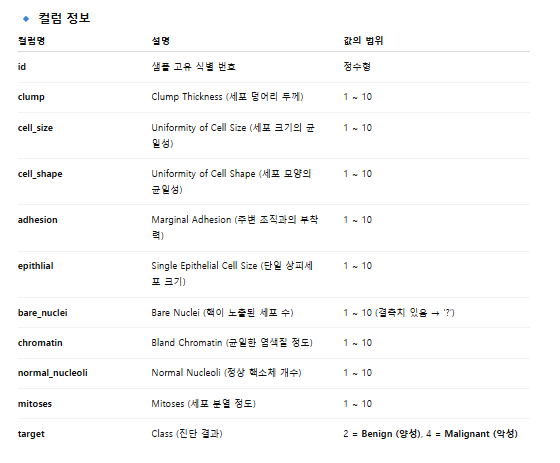

In [20]:
import pandas as pd
import numpy as np
# Breast Cancer 데이터셋 가져오기 (출처: UCI ML Repository)
uci_path = 'https://archive.ics.uci.edu/ml/machine-learning-databases/\
breast-cancer-wisconsin/breast-cancer-wisconsin.data'
df = pd.read_csv(uci_path, header=None)

# 열 이름 지정
df.columns = ['id', 'clump', 'cell_size', 'cell_shape', 'adhesion', 'epithlial',
              'bare_nuclei', 'chromatin', 'normal_nucleoli', 'mitoses', 'target']

# 데이터셋의 크기
print(df.shape)
df.head()
np.unique(df.target)

(699, 11)


array([2, 4])

In [21]:
# 타겟의 2와 4를 0과 1로 변경

df.target = df.target.map({2:0, 4:1})
df.head()
np.unique(df.target)

array([0, 1])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               699 non-null    int64 
 1   clump            699 non-null    int64 
 2   cell_size        699 non-null    int64 
 3   cell_shape       699 non-null    int64 
 4   adhesion         699 non-null    int64 
 5   epithlial        699 non-null    int64 
 6   bare_nuclei      699 non-null    object
 7   chromatin        699 non-null    int64 
 8   normal_nucleoli  699 non-null    int64 
 9   mitoses          699 non-null    int64 
 10  target           699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [28]:
df.bare_nuclei=pd.to_numeric(df.bare_nuclei, errors='coerce')
df.info()
df.isna().mean() #전체대비 대략 2%
df=df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               699 non-null    int64  
 1   clump            699 non-null    int64  
 2   cell_size        699 non-null    int64  
 3   cell_shape       699 non-null    int64  
 4   adhesion         699 non-null    int64  
 5   epithlial        699 non-null    int64  
 6   bare_nuclei      683 non-null    float64
 7   chromatin        699 non-null    int64  
 8   normal_nucleoli  699 non-null    int64  
 9   mitoses          699 non-null    int64  
 10  target           699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


In [34]:
# X,y 뽑아내기
X = df.drop(columns=['id','target']).to_numpy()
y = df.target

# 데이터 분리 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.3,random_state=42)

In [48]:
# 모델 선택
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3)

# 학습
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
#평가1
from sklearn.metrics import classification_report
y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))

# ==> 아무것도 처리 안했을 때 결과가 이렇게 나옴 ==> baseline

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [51]:
#평가2 : 과적합 확인 및 보정
from sklearn.metrics import classification_report

# 학습한 데이터를 평가
# 학습하지 않은 데이터를 평가
# 두 수치가 차이가 많이 나면 ==> 과적합
     # 과대적합 : 학습>평가 overfitting    
     # 과소적합 : 학습<평가 underfitting   
     # 학습과 평가의 결과 차이가 0.05 이상이면 과적합

# 학습에 대한 결과 확인 (train)
y_train_pred = tree.predict(X_train)
print(classification_report(y_train, y_train_pred))

# 평가
y_pred = tree.predict(X_test)
print(classification_report(y_test, y_pred))



# 학습 : 1.00 나왔는데, depth 지정안해줬더니 tree가 가장 아래까지 진행되서 1.00 이 됨 ==> 학습과 평가 차이가 큼/ 과적합/
# 그래서 위에 셀에서 학습을 tree = DecisionTreeClassifier(max_depth=3) 이렇게 변경하니 0.97 로 변경
# 학습과 평가 차이가 줄어들어서 과적합X

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       311
           1       0.96      0.94      0.95       167

    accuracy                           0.97       478
   macro avg       0.97      0.96      0.96       478
weighted avg       0.97      0.97      0.97       478

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

knn = KNeighborsClassifier()
svm = SVC()

knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print('knn f1-score')
print(classification_report(y_test,y_pred))

print('svm f1-score')
y_pred = svm.predict(X_test)
print(classification_report(y_test,y_pred))

knn f1-score
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       133
           1       0.93      0.93      0.93        72

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205

svm f1-score
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       133
           1       0.93      0.97      0.95        72

    accuracy                           0.97       205
   macro avg       0.96      0.97      0.96       205
weighted avg       0.97      0.97      0.97       205



In [53]:
####### 스케일링 추가 

# 모델 선택
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


# 스케일링
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

# 모델 생성
knn = KNeighborsClassifier()
svm = SVC()


# 모델별 학습
knn.fit(x_train_scaled, y_train)
svm.fit(x_train_scaled, y_train)



#예측
knn_predict = knn.predict(x_test_scaled)
svm_predict = svm.predict(x_test_scaled)


#예측/평가
print(f'knn 모델 : {classification_report(y_test,knn_predict)}')
print(f'svm 모델 : {classification_report(y_test,svm_predict)}')


knn 모델 :               precision    recall  f1-score   support

           0       0.97      0.96      0.97       133
           1       0.93      0.94      0.94        72

    accuracy                           0.96       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205

svm 모델 :               precision    recall  f1-score   support

           0       0.98      0.96      0.97       133
           1       0.93      0.96      0.95        72

    accuracy                           0.96       205
   macro avg       0.95      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205

